# HBL Improved BiLSTM Model — v2

## What changed from v1 and WHY

| Change | v1 (Old) | v2 (New) | Why |
|--------|----------|----------|-----|
| **Target** | Next-day log return | **5-day forward log return** | Daily returns ≈ random walk. 5-day horizon carries more signal from momentum + sentiment |
| **Loss function** | MSE only | **MSE + Directional Penalty** | Pure MSE rewards always predicting ~0. Directional loss penalizes wrong-sign predictions |
| **Sentiment features** | Raw sent_3, sent_7 (negative importance) | **Sentiment Surprise + Sentiment Momentum** | Engineered features carry more signal than raw averages |
| **Architecture** | BiLSTM only | **BiLSTM + Attention layer** | Attention lets the model focus on the most important timesteps in the 30-day window |
| **Trading signal** | Long if pred > 0 | **Long only if pred > threshold** | Filters near-zero noise predictions; only acts on high-conviction signals |
| **Sequence length** | 30 days | **30 days** (unchanged — still good) | — |


## Section 1 — Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Bidirectional, LSTM, Dense, Dropout,
    LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Hyperparameters (all in one place — easy to tune) ────────────────────────
SEQUENCE_LENGTH  = 30        # Days of history the model looks back
FORWARD_DAYS     = 5         # NEW: predict 5-day forward return (was 1)
LSTM_UNITS_1     = 128       # First BiLSTM layer units
LSTM_UNITS_2     = 64        # Second BiLSTM layer units
ATTENTION_HEADS  = 4         # NEW: Multi-head attention heads
ATTENTION_KEY_DIM= 32        # NEW: Attention key dimension
DROPOUT_RATE     = 0.3
LEARNING_RATE    = 1e-3
BATCH_SIZE       = 32
MAX_EPOCHS       = 100
DIRECTION_WEIGHT = 0.7       # NEW: Weight of directional loss term (tune this)
SIGNAL_THRESHOLD = 0.002     # NEW: Only trade when |pred| > 0.2% (tune on val)

# Splits: 70% train / 15% val / 15% test
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15

DATA_PATH = r'C:\Users\Admin\Desktop\Fyp Working\model training v3\hbl_merged_dataset_clean.csv'
MODEL_SAVE_PATH = r'hbl_merged_dataset_clean\bilstm_return_regression.keras'
SCALER_SAVE_PATH = r'C:\Users\Admin\Desktop\Fyp Working\model training v3\feature_scaler.pkl'

print('✅ Configuration loaded')
print(f'   Target horizon : {FORWARD_DAYS}-day forward log return')
print(f'   Sequence length: {SEQUENCE_LENGTH} days')
print(f'   Direction weight in loss: {DIRECTION_WEIGHT}')
print(f'   Signal threshold: ±{SIGNAL_THRESHOLD:.3f}')

C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framewo

✅ Configuration loaded
   Target horizon : 5-day forward log return
   Sequence length: 30 days
   Direction weight in loss: 0.7
   Signal threshold: ±0.002


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## Section 2 — Load Data & Engineer Features

### What's new vs v1

**Dropped/replaced (had negative importance in v1):**
- `sent_3`, `sent_7` (raw 3-day and 7-day sentiment averages) → replaced by **sentiment surprise** and **sentiment momentum**

**New features:**
- `sent_surprise` — daily sentiment minus its 10-day rolling mean. Captures *unexpected* sentiment shifts, which carry more signal than the level itself.
- `sent_momentum` — difference between 3-day and 7-day sentiment moving averages. Measures whether sentiment is improving or worsening.
- `atr_14` — Average True Range (14-day), a proper volatility measure.
- `bb_width` — Bollinger Band width. Wide = high volatility regime.
- `rsi_14` — Relative Strength Index. Overbought/oversold signal.
- `volume_ratio` — Volume vs 20-day average. Detects unusual activity.

**New target:**
- `target_5d` — sum of the next 5 log returns. This is what the model will now predict.

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f'Loaded {len(df)} rows  |  {df["date"].min().date()} → {df["date"].max().date()}')

# ── Technical features ────────────────────────────────────────────────────────
df['ret_1']  = df['log_return']                              # Same-day log return
df['ret_5']  = df['log_return'].rolling(5).sum()            # 5-day cumulative return
df['ret_10'] = df['log_return'].rolling(10).sum()           # 10-day cumulative return
df['ret_20'] = df['log_return'].rolling(20).sum()           # 20-day cumulative return

# Volatility (rolling standard deviation of returns)
df['vol_5']  = df['log_return'].rolling(5).std()
df['vol_10'] = df['log_return'].rolling(10).std()
df['vol_20'] = df['log_return'].rolling(20).std()

# Price momentum (close vs moving average)
df['sma_10'] = df['Close'].rolling(10).mean()
df['sma_20'] = df['Close'].rolling(20).mean()
df['mom_10'] = (df['Close'] - df['sma_10']) / df['sma_10']  # % above/below SMA10
df['mom_20'] = (df['Close'] - df['sma_20']) / df['sma_20']  # % above/below SMA20

# Average True Range (ATR-14) — pure volatility measure
high_low   = df['High'] - df['Low']
high_close = (df['High'] - df['Close'].shift(1)).abs()
low_close  = (df['Low']  - df['Close'].shift(1)).abs()
true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df['atr_14'] = true_range.rolling(14).mean() / df['Close']  # Normalised by price

# Bollinger Bands width
rolling_std = df['Close'].rolling(20).std()
bb_upper = df['sma_20'] + 2 * rolling_std
bb_lower = df['sma_20'] - 2 * rolling_std
df['bb_width'] = (bb_upper - bb_lower) / df['sma_20']
df['bb_pos']   = (df['Close'] - bb_lower) / (bb_upper - bb_lower + 1e-9)  # Position within bands

# RSI-14
delta = df['Close'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
rs = gain / (loss + 1e-9)
df['rsi_14'] = 1 - 1 / (1 + rs)  # Normalised 0-1 (instead of 0-100)

# Volume relative to 20-day average
df['volume_ratio'] = df['Volume'] / (df['Volume'].rolling(20).mean() + 1e-9)

# ── Sentiment features (v2 — engineered, not raw averages) ───────────────────
# Sentiment surprise: today's sentiment vs recent average
# Captures *unexpected* sentiment shifts rather than level
df['sent_mean_10'] = df['daily_sentiment'].rolling(10).mean()
df['sent_surprise'] = df['daily_sentiment'] - df['sent_mean_10']

# Sentiment momentum: short-term minus medium-term average
# Positive = sentiment is improving, Negative = deteriorating
df['sent_ma3'] = df['daily_sentiment'].rolling(3).mean()
df['sent_ma7'] = df['daily_sentiment'].rolling(7).mean()
df['sent_momentum'] = df['sent_ma3'] - df['sent_ma7']

# News volume relative to average (is there unusual news activity?)
df['news_volume_ratio'] = df['daily_news_count'] / (df['daily_news_count'].rolling(20).mean() + 1e-9)

# Quarterly and annual sentiment (kept — had positive importance)
# Already in df as: quarterly_sentiment, annual_sentiment, daily_sentiment

# ── NEW TARGET: 5-day forward cumulative log return ───────────────────────────
# The original model predicted log_return_next (1-day) which is near-random.
# We now predict the SUM of the next FORWARD_DAYS log returns.
# This horizon carries more signal from momentum and sentiment.
df['target_5d'] = df['log_return'].shift(-FORWARD_DAYS).rolling(FORWARD_DAYS).sum().shift(-(FORWARD_DAYS-1))
# Cleaner way:
df['target_5d'] = sum(df['log_return'].shift(-i) for i in range(1, FORWARD_DAYS + 1))

# ── Feature list ──────────────────────────────────────────────────────────────
# These are the features fed into the model
FEATURE_COLS = [
    # Price-based
    'ret_1', 'ret_5', 'ret_10', 'ret_20',
    # Volatility
    'vol_5', 'vol_10', 'vol_20', 'atr_14',
    # Momentum
    'mom_10', 'mom_20',
    # Oscillators / bands
    'rsi_14', 'bb_width', 'bb_pos',
    # Volume
    'volume_ratio',
    # Sentiment (engineered — NOT raw averages)
    'daily_sentiment',      # Level (small positive importance in v1)
    'sent_surprise',        # NEW: Unexpected shift
    'sent_momentum',        # NEW: Trend in sentiment
    'news_volume_ratio',    # NEW: Is there unusual news activity?
    'quarterly_sentiment',  # Fundamental backdrop
    'annual_sentiment',     # Long-term sentiment context
]

TARGET_COL = 'target_5d'

# Drop rows with NaN (from rolling windows and the shifted target)
df_clean = df[FEATURE_COLS + [TARGET_COL, 'date', 'Close', 'log_return']].dropna().reset_index(drop=True)

print(f'\nClean dataset: {len(df_clean)} rows after removing NaN')
print(f'Features: {len(FEATURE_COLS)}')
print(f'\nTarget ({TARGET_COL}) statistics:')
print(df_clean[TARGET_COL].describe())

Loaded 2503 rows  |  2015-12-31 → 2025-08-28

Clean dataset: 2479 rows after removing NaN
Features: 20

Target (target_5d) statistics:
count    2479.000000
mean        0.002024
std         0.048871
min        -0.293040
25%        -0.025914
50%        -0.002160
75%         0.026484
max         0.274099
Name: target_5d, dtype: float64


## Section 3 — Train / Validation / Test Split

In [3]:
n = len(df_clean)
train_end = int(n * TRAIN_RATIO)
val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))

train_df = df_clean.iloc[:train_end]
val_df   = df_clean.iloc[train_end:val_end]
test_df  = df_clean.iloc[val_end:]

print(f'Train : {len(train_df):4d} rows  ({train_df["date"].min().date()} → {train_df["date"].max().date()})')
print(f'Val   : {len(val_df):4d}  rows  ({val_df["date"].min().date()} → {val_df["date"].max().date()})')
print(f'Test  : {len(test_df):4d} rows  ({test_df["date"].min().date()} → {test_df["date"].max().date()})')

# ── Scaling ───────────────────────────────────────────────────────────────────
# RobustScaler is better than StandardScaler for financial data
# because it uses median/IQR and is resistant to outliers
from sklearn.preprocessing import RobustScaler
import pickle

feature_scaler = RobustScaler()
target_scaler  = RobustScaler()

# Fit ONLY on training data — never look at val/test
X_train_scaled = feature_scaler.fit_transform(train_df[FEATURE_COLS])
y_train_scaled = target_scaler.fit_transform(train_df[[TARGET_COL]])

X_val_scaled   = feature_scaler.transform(val_df[FEATURE_COLS])
y_val_scaled   = target_scaler.transform(val_df[[TARGET_COL]])

X_test_scaled  = feature_scaler.transform(test_df[FEATURE_COLS])
y_test_scaled  = target_scaler.transform(test_df[[TARGET_COL]])

# Save scalers
import os
os.makedirs(os.path.dirname(SCALER_SAVE_PATH), exist_ok=True)
with open(SCALER_SAVE_PATH, 'wb') as f:
    pickle.dump({'feature_scaler': feature_scaler, 'target_scaler': target_scaler}, f)

print('\n✅ Scalers fitted and saved')

Train : 1735 rows  (2016-01-27 → 2022-09-21)
Val   :  372  rows  (2022-09-22 → 2024-02-26)
Test  :  372 rows  (2024-02-27 → 2025-08-21)

✅ Scalers fitted and saved


## Section 4 — Build Sequences

Each sample is a 30-day window of features → 1 target value (5-day forward return).

In [4]:
def build_sequences(X_scaled, y_scaled, seq_len):
    """
    Build (samples, seq_len, features) arrays for LSTM input.
    Each sample: X[t-seq_len : t]  →  y[t]
    """
    X_seqs, y_seqs = [], []
    for i in range(seq_len, len(X_scaled)):
        X_seqs.append(X_scaled[i - seq_len : i])
        y_seqs.append(y_scaled[i])
    return np.array(X_seqs, dtype=np.float32), np.array(y_seqs, dtype=np.float32)

X_tr, y_tr = build_sequences(X_train_scaled, y_train_scaled, SEQUENCE_LENGTH)
X_va, y_va = build_sequences(X_val_scaled,   y_val_scaled,   SEQUENCE_LENGTH)
X_te, y_te = build_sequences(X_test_scaled,  y_test_scaled,  SEQUENCE_LENGTH)

# Also store unscaled targets for evaluation
_, y_tr_raw = build_sequences(X_train_scaled, train_df[[TARGET_COL]].values, SEQUENCE_LENGTH)
_, y_va_raw = build_sequences(X_val_scaled,   val_df[[TARGET_COL]].values,   SEQUENCE_LENGTH)
_, y_te_raw = build_sequences(X_test_scaled,  test_df[[TARGET_COL]].values,  SEQUENCE_LENGTH)

print(f'X_train shape: {X_tr.shape}  →  y_train shape: {y_tr.shape}')
print(f'X_val shape  : {X_va.shape}  →  y_val shape  : {y_va.shape}')
print(f'X_test shape : {X_te.shape}  →  y_test shape : {y_te.shape}')

X_train shape: (1705, 30, 20)  →  y_train shape: (1705, 1)
X_val shape  : (342, 30, 20)  →  y_val shape  : (342, 1)
X_test shape : (342, 30, 20)  →  y_test shape : (342, 1)


## Section 5 — Custom Directional Loss

### Why MSE fails for return prediction

When targets are mostly near-zero (as daily/weekly returns are), MSE has a mathematical "trap":
the loss is minimised by always predicting ~0. The model never gets penalised for predicting
the wrong direction — only for magnitude errors.

### The fix: Directional Loss

```
Loss = MSE + λ × Direction_Penalty

Direction_Penalty = mean( ReLU( -y_true × y_pred ) )
```

The `ReLU(-y_true × y_pred)` term is **0** when signs agree (correct direction)
and **positive** when signs disagree (wrong direction). So the model now gets
penalised for both:
1. Magnitude error (MSE)
2. Being in the wrong direction

`DIRECTION_WEIGHT` (λ) controls how much to emphasise direction vs magnitude.
Start at 0.7 — you can tune this on the validation set.

In [5]:
def directional_loss(direction_weight=0.7):
    """
    Returns a loss function: MSE + direction_weight × direction_penalty.
    
    direction_penalty = mean(ReLU(-y_true * y_pred))
      → 0 when predicted sign matches actual sign (correct direction)
      → positive when signs disagree (wrong direction)
    """
    def loss(y_true, y_pred):
        mse = K.mean(K.square(y_true - y_pred))
        direction_penalty = K.mean(K.relu(-y_true * y_pred))
        return mse + direction_weight * direction_penalty
    loss.__name__ = f'directional_loss_w{direction_weight}'
    return loss

# Test it compiles
test_loss = directional_loss(DIRECTION_WEIGHT)
print(f'✅ Custom loss function: {test_loss.__name__}')
print(f'   Formula: MSE + {DIRECTION_WEIGHT} × ReLU(-y_true × y_pred)')

✅ Custom loss function: directional_loss_w0.7
   Formula: MSE + 0.7 × ReLU(-y_true × y_pred)


## Section 6 — Model Architecture

### What's new vs v1

**Multi-Head Attention layer added after BiLSTM stack.**

Why? A 30-day sequence contains a mix of relevant and irrelevant timesteps. 
The Attention mechanism learns to *weight* each timestep dynamically:
- High weight → this day was important for predicting the next 5-day return
- Low weight  → this day was noise

This is especially useful because sentiment spikes and volatility events happen 
on specific days within the window, and attention can learn to focus on them.

```
Input (30, 20)
  │
  ├─ BiLSTM(128, return_sequences=True)   → (30, 256)
  ├─ LayerNorm + Dropout
  │
  ├─ BiLSTM(64, return_sequences=True)    → (30, 128)
  ├─ LayerNorm + Dropout
  │
  ├─ MultiHeadAttention(4 heads)          → (30, 128)   ← NEW
  ├─ LayerNorm (residual)
  │
  ├─ GlobalAveragePooling1D               → (128,)      ← Pools over time
  ├─ Dense(64, relu) + Dropout
  ├─ Dense(32, relu)
  └─ Dense(1, linear)                     → scalar prediction
```

In [6]:
def build_bilstm_attention(seq_len, n_features,
                           lstm_units_1=128, lstm_units_2=64,
                           attn_heads=4, attn_key_dim=32,
                           dropout_rate=0.3):
    """
    BiLSTM + Multi-Head Attention model for regression.
    """
    inputs = Input(shape=(seq_len, n_features), name='sequence_input')

    # ── First BiLSTM block ────────────────────────────────────────────────────
    # return_sequences=True: pass full sequence to next layer (not just last step)
    x = Bidirectional(
        LSTM(lstm_units_1, return_sequences=True, dropout=dropout_rate,
             recurrent_dropout=0.1),
        name='bilstm_1'
    )(inputs)
    x = LayerNormalization(name='layernorm_1')(x)
    x = Dropout(dropout_rate, name='dropout_1')(x)

    # ── Second BiLSTM block ───────────────────────────────────────────────────
    x = Bidirectional(
        LSTM(lstm_units_2, return_sequences=True, dropout=dropout_rate,
             recurrent_dropout=0.1),
        name='bilstm_2'
    )(x)
    x = LayerNormalization(name='layernorm_2')(x)
    x = Dropout(dropout_rate, name='dropout_2')(x)

    # ── Multi-Head Attention (NEW) ─────────────────────────────────────────────
    # Self-attention: query=key=value=x (the LSTM output)
    # The model learns which timesteps in the 30-day window to pay attention to
    attn_out = MultiHeadAttention(
        num_heads=attn_heads, key_dim=attn_key_dim,
        dropout=dropout_rate, name='multi_head_attention'
    )(x, x)  # query=x, key/value=x → self-attention
    
    # Residual connection: add attention output to input
    # This helps gradients flow during training (prevents vanishing gradient)
    x = LayerNormalization(name='layernorm_attn')(x + attn_out)

    # ── Aggregate across time ─────────────────────────────────────────────────
    # GlobalAveragePooling1D: average over all 30 timesteps → single vector
    # (Better than just taking last timestep — uses all attended information)
    x = GlobalAveragePooling1D(name='global_avg_pool')(x)

    # ── Dense head ────────────────────────────────────────────────────────────
    x = Dense(64, activation='relu', name='dense_1')(x)
    x = Dropout(dropout_rate / 2, name='dropout_3')(x)
    x = Dense(32, activation='relu', name='dense_2')(x)
    outputs = Dense(1, activation='linear', name='output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='BiLSTM_Attention_v2')
    return model


model = build_bilstm_attention(
    seq_len     = SEQUENCE_LENGTH,
    n_features  = len(FEATURE_COLS),
    lstm_units_1= LSTM_UNITS_1,
    lstm_units_2= LSTM_UNITS_2,
    attn_heads  = ATTENTION_HEADS,
    attn_key_dim= ATTENTION_KEY_DIM,
    dropout_rate= DROPOUT_RATE
)

model.compile(
    optimizer = Adam(learning_rate=LEARNING_RATE),
    loss      = directional_loss(DIRECTION_WEIGHT),
    metrics   = ['mae']
)

model.summary()

Model: "BiLSTM_Attention_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)   │ (None, 30, 20)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bilstm_1 (Bidirectional)      │ (None, 30, 256)           │         152,576 │ sequence_input[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layernorm_1                   │ (None, 30, 256)           │             512 │ bilstm_1[0][0]             │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 30, 256)           │               0 │ layernorm_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bilstm_2 (Bidirectional)      │ (None, 30, 128)           │         164,352 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layernorm_2                   │ (None, 30, 128)           │             256 │ bilstm_2[0][0]             │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 30, 128)           │               0 │ layernorm_2[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_head_attention          │ (None, 30, 128)           │          66,048 │ dropout_2[0][0],           │
│ (MultiHeadAttention)          │                           │                 │ dropout_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 30, 128)           │               0 │ dropout_2[0][0],           │
│                               │                           │                 │ multi_head_attention[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ layernorm_attn                │ (None, 30, 128)           │             256 │ add[0][0]                  │
│ (LayerNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_avg_pool               │ (None, 128)               │               0 │ layernorm_attn[0][0]       │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 64)                │           8,256 │ global_avg_pool[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_3 (Dropout)           │ (None, 64)                │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 32)                │           2,080 │ dropout_3[0][0]            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 394,369 (1.50 MB)

 Trainable params: 394,369 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

## Section 7 — Training with Callbacks

In [7]:
callbacks = [
    # Stop training if val_loss doesn't improve for 15 epochs
    EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    # Halve learning rate if val_loss plateaus for 7 epochs
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7,
        min_lr=1e-6, verbose=1
    ),
    # Save the best model to disk
    ModelCheckpoint(
        MODEL_SAVE_PATH, monitor='val_loss',
        save_best_only=True, verbose=0
    )
]

print('🚀 Starting training...')
history = model.fit(
    X_tr, y_tr,
    validation_data = (X_va, y_va),
    epochs          = MAX_EPOCHS,
    batch_size      = BATCH_SIZE,
    callbacks       = callbacks,
    verbose         = 1
)
print('\n✅ Training complete')

🚀 Starting training...
Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - loss: 0.8782 - mae: 0.6795 - val_loss: 1.0709 - val_mae: 0.7163 - learning_rate: 0.0010
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.8145 - mae: 0.6539 - val_loss: 1.2218 - val_mae: 0.7366 - learning_rate: 0.0010
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.7877 - mae: 0.6432 - val_loss: 1.1408 - val_mae: 0.7199 - learning_rate: 0.0010
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.7664 - mae: 0.6408 - val_loss: 1.1910 - val_mae: 0.7549 - learning_rate: 0.0010
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 0.7047 - mae: 0.6154 - val_loss: 1.2252 - val_mae: 0.7652 - learning_rate: 0.0010
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.7169 - mae: 0.6189 - val_loss: 1.2247 - val_mae: 0.7530 - learning_rate: 0.0010
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 0.6820 - mae: 0.6063 - val_loss: 1.1059 - val_mae: 0.7352 - lea

## Section 8 — Training Curves

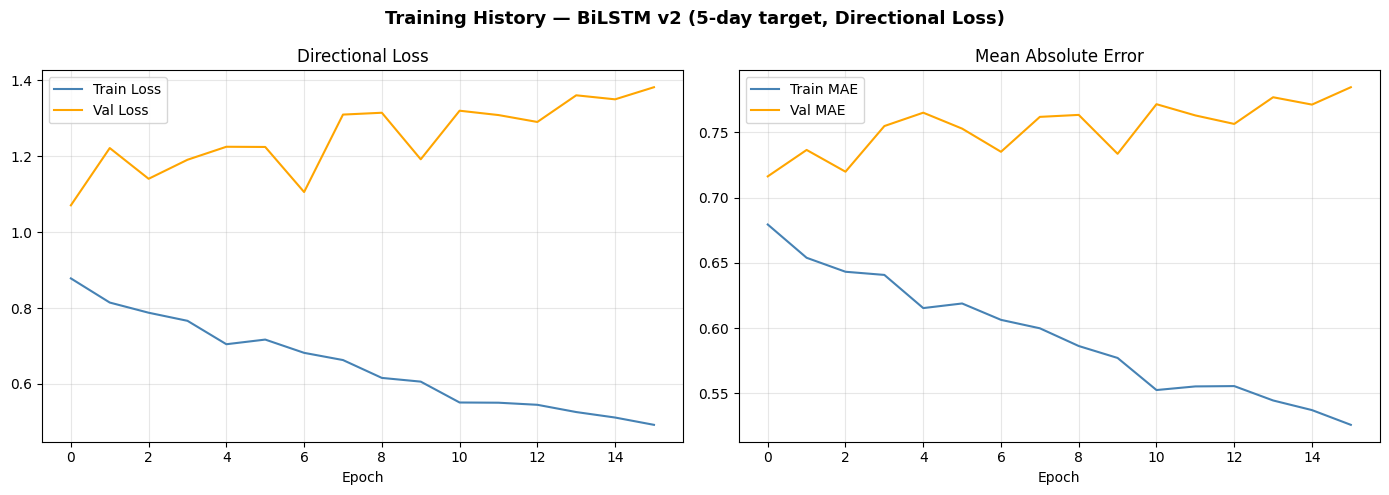

Best val_loss: 1.070853  at epoch 1


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — BiLSTM v2 (5-day target, Directional Loss)', fontsize=13, fontweight='bold')

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='orange')
axes[0].set_title('Directional Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'],     label='Train MAE', color='steelblue')
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='orange')
axes[1].set_title('Mean Absolute Error')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best val_loss: {min(history.history["val_loss"]):.6f}  at epoch {np.argmin(history.history["val_loss"]) + 1}')

## Section 9 — Predictions & Inverse Transform

In [9]:
# Generate predictions (in scaled space)
pred_tr_scaled = model.predict(X_tr, verbose=0)
pred_va_scaled = model.predict(X_va, verbose=0)
pred_te_scaled = model.predict(X_te, verbose=0)

# Inverse transform back to actual return space
pred_tr = target_scaler.inverse_transform(pred_tr_scaled).flatten()
pred_va = target_scaler.inverse_transform(pred_va_scaled).flatten()
pred_te = target_scaler.inverse_transform(pred_te_scaled).flatten()

# True values
true_tr = y_tr_raw.flatten()
true_va = y_va_raw.flatten()
true_te = y_te_raw.flatten()

print('Prediction ranges:')
print(f'  Train pred: [{pred_tr.min():.4f}, {pred_tr.max():.4f}]   True: [{true_tr.min():.4f}, {true_tr.max():.4f}]')
print(f'  Val   pred: [{pred_va.min():.4f}, {pred_va.max():.4f}]   True: [{true_va.min():.4f}, {true_va.max():.4f}]')
print(f'  Test  pred: [{pred_te.min():.4f}, {pred_te.max():.4f}]   True: [{true_te.min():.4f}, {true_te.max():.4f}]')

# KEY CHECK: Is the model still stuck near zero?
pred_std = pred_te.std()
true_std = true_te.std()
print(f'\nTest  pred std: {pred_std:.5f}   True std: {true_std:.5f}')
print(f'Pred/True std ratio: {pred_std/true_std:.3f}  (v1 was ~0.05 — should be higher now)')

Prediction ranges:
  Train pred: [-0.0435, 0.0493]   True: [-0.2930, 0.2090]
  Val   pred: [-0.0354, 0.0294]   True: [-0.1054, 0.2248]
  Test  pred: [-0.0261, 0.0145]   True: [-0.0962, 0.2741]

Test  pred std: 0.00955   True std: 0.06037
Pred/True std ratio: 0.158  (v1 was ~0.05 — should be higher now)


## Section 10 — Evaluation Metrics

In [10]:
def evaluate_predictions(y_true, y_pred, label=''):
    """Compute regression + directional metrics."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2   = 1 - ss_res / ss_tot
    r, _ = stats.pearsonr(y_true, y_pred)
    
    # Directional accuracy
    correct_dir = np.mean(np.sign(y_true) == np.sign(y_pred))
    
    return {
        'Set': label, 'RMSE': rmse, 'MAE': mae,
        'R²': r2, 'Pearson r': r, 'Dir Acc': correct_dir
    }

results = [
    evaluate_predictions(true_tr, pred_tr, 'Train'),
    evaluate_predictions(true_va, pred_va, 'Val'),
    evaluate_predictions(true_te, pred_te, 'Test'),
]

results_df = pd.DataFrame(results).set_index('Set')

# Format nicely
fmt = {'RMSE': '{:.5f}', 'MAE': '{:.5f}', 'R²': '{:.4f}', 'Pearson r': '{:.4f}', 'Dir Acc': '{:.1%}'}
print('\n═══ Model v2 Performance ═══')
print(results_df.to_string(float_format=lambda x: f'{x:.4f}'))

print('\n─── Benchmark ───')
print('v1 Pearson r (test): 0.017   Dir Acc: 51.6%')
print(f'v2 Pearson r (test): {results_df.loc["Test", "Pearson r"]:.3f}   Dir Acc: {results_df.loc["Test", "Dir Acc"]:.1%}')
print(f'v1 R² (test)       : -0.041')
print(f'v2 R² (test)       : {results_df.loc["Test", "R²"]:.4f}')


═══ Model v2 Performance ═══
        RMSE    MAE      R²  Pearson r  Dir Acc
Set                                            
Train 0.0429 0.0319  0.1077     0.3345   0.5906
Val   0.0512 0.0363 -0.0673     0.0690   0.5058
Test  0.0629 0.0453 -0.0867     0.0884   0.5205

─── Benchmark ───
v1 Pearson r (test): 0.017   Dir Acc: 51.6%
v2 Pearson r (test): 0.088   Dir Acc: 52.0%
v1 R² (test)       : -0.041
v2 R² (test)       : -0.0867


## Section 11 — Actual vs Predicted Plot

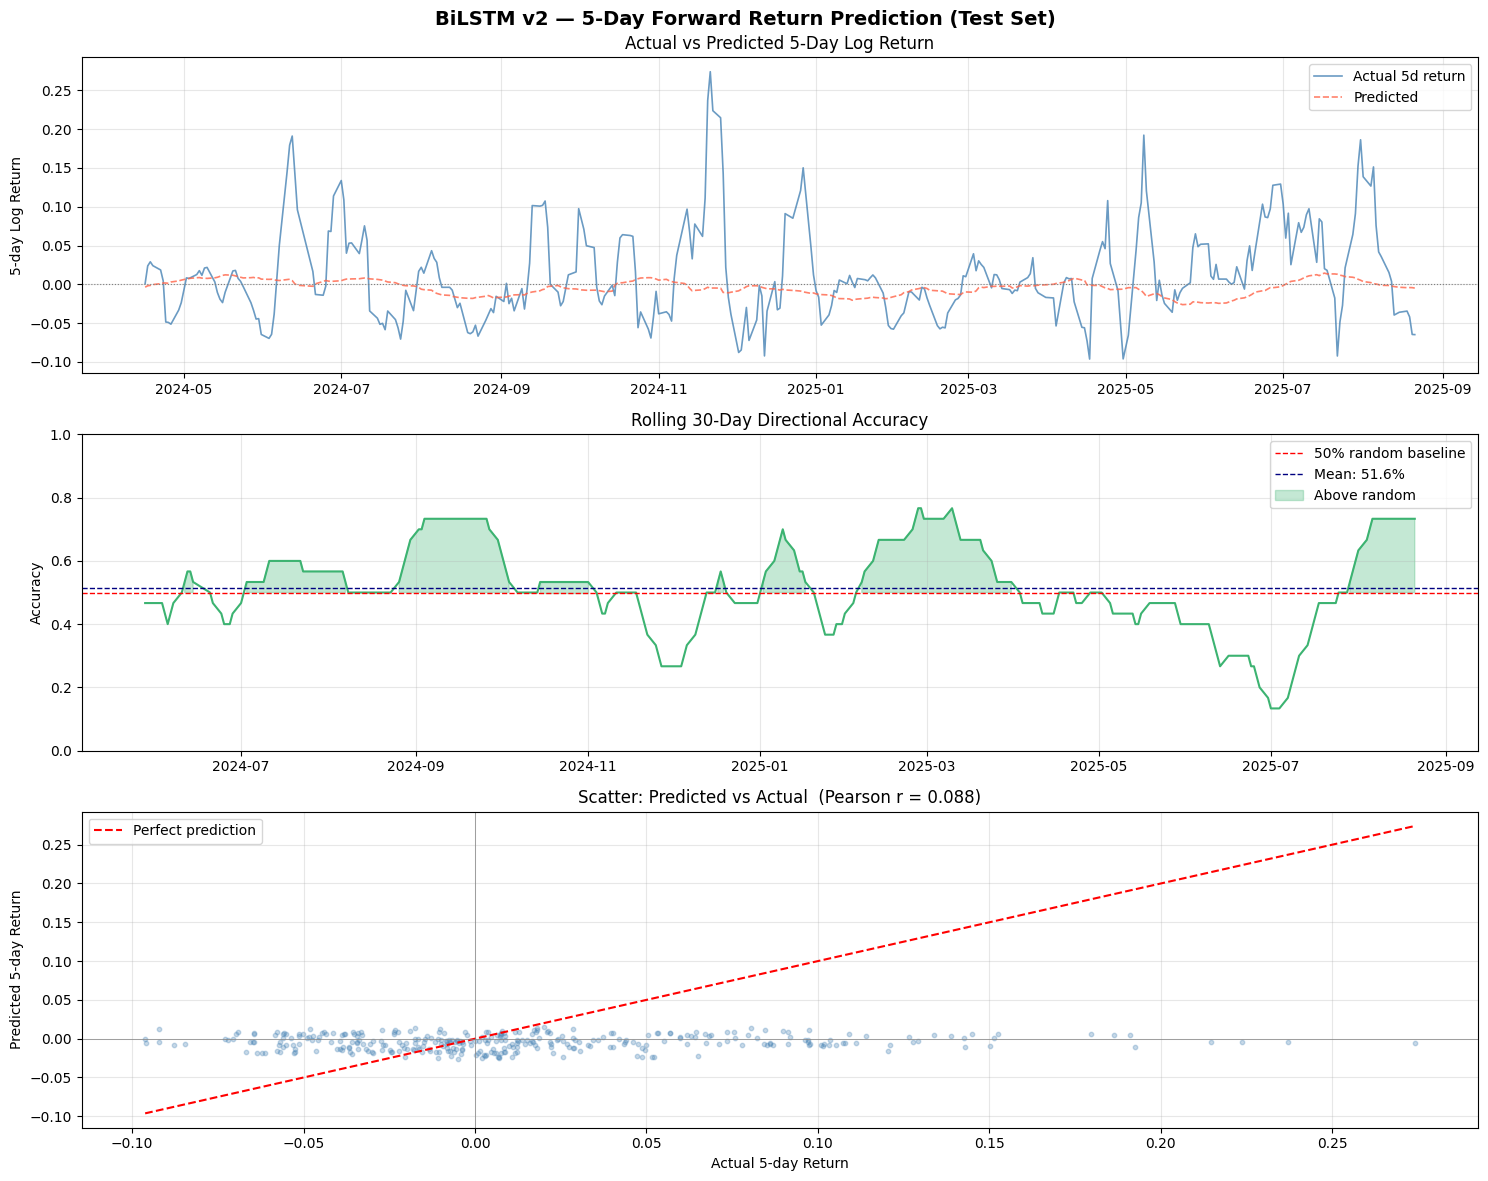

In [11]:
# Date axis for test set
test_dates = test_df['date'].values[SEQUENCE_LENGTH:]

fig, axes = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle('BiLSTM v2 — 5-Day Forward Return Prediction (Test Set)', fontsize=14, fontweight='bold')

# Plot 1: Actual vs Predicted
ax = axes[0]
ax.plot(test_dates, true_te, label='Actual 5d return', color='steelblue', alpha=0.8, linewidth=1.2)
ax.plot(test_dates, pred_te, label='Predicted',       color='tomato',    alpha=0.8, linewidth=1.2, linestyle='--')
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.set_title('Actual vs Predicted 5-Day Log Return')
ax.set_ylabel('5-day Log Return')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Plot 2: Rolling 30-day directional accuracy
ax2 = axes[1]
correct = (np.sign(true_te) == np.sign(pred_te)).astype(int)
rolling_acc = pd.Series(correct).rolling(30).mean().values
ax2.plot(test_dates, rolling_acc, color='mediumseagreen', linewidth=1.5)
ax2.axhline(0.5, color='red', linewidth=1, linestyle='--', label='50% random baseline')
ax2.axhline(rolling_acc[~np.isnan(rolling_acc)].mean(), color='navy', linewidth=1,
            linestyle='--', label=f'Mean: {np.nanmean(rolling_acc):.1%}')
ax2.fill_between(test_dates, 0.5, rolling_acc, where=(rolling_acc > 0.5),
                  alpha=0.3, color='mediumseagreen', label='Above random')
ax2.set_title('Rolling 30-Day Directional Accuracy')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Plot 3: Scatter — Predicted vs Actual
ax3 = axes[2]
r_val = stats.pearsonr(true_te, pred_te)[0]
ax3.scatter(true_te, pred_te, alpha=0.3, s=10, color='steelblue')
lims = [min(true_te.min(), pred_te.min()), max(true_te.max(), pred_te.max())]
ax3.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax3.axhline(0, color='gray', linewidth=0.5)
ax3.axvline(0, color='gray', linewidth=0.5)
ax3.set_title(f'Scatter: Predicted vs Actual  (Pearson r = {r_val:.3f})')
ax3.set_xlabel('Actual 5-day Return')
ax3.set_ylabel('Predicted 5-day Return')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predictions_v2.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 12 — Residual Analysis

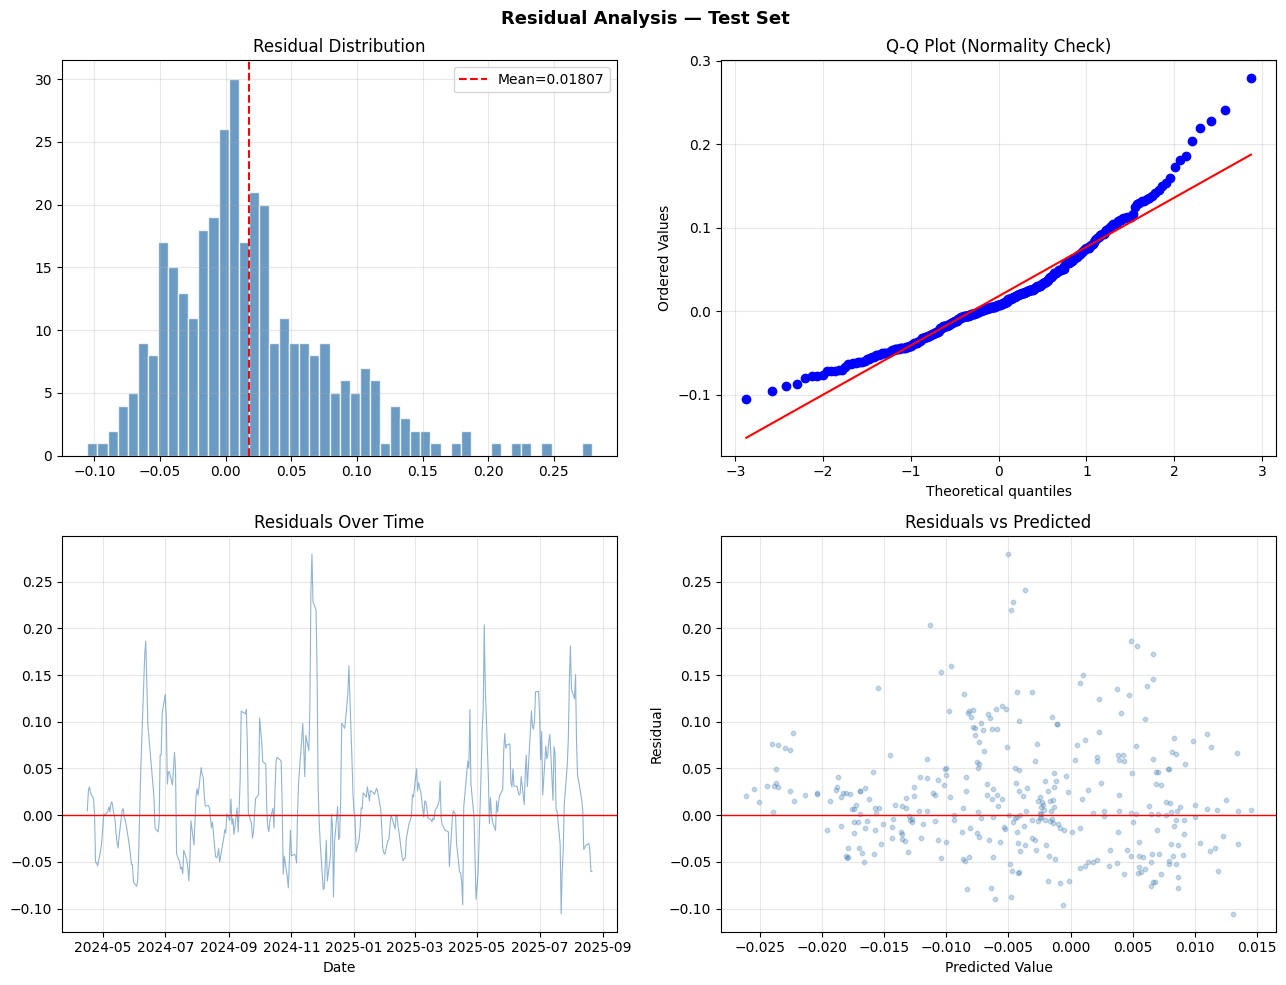

Residual stats: mean=0.018072, std=0.060280, skew=1.026


In [12]:
residuals = true_te - pred_te

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Residual Analysis — Test Set', fontsize=13, fontweight='bold')

# Residual distribution
axes[0, 0].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 0].axvline(residuals.mean(), color='red', linestyle='--', label=f'Mean={residuals.mean():.5f}')
axes[0, 0].set_title('Residual Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(residuals, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normality Check)')
axes[0, 1].grid(True, alpha=0.3)

# Residuals over time
axes[1, 0].plot(test_dates, residuals, color='steelblue', alpha=0.6, linewidth=0.8)
axes[1, 0].axhline(0, color='red', linewidth=1)
axes[1, 0].set_title('Residuals Over Time')
axes[1, 0].set_xlabel('Date')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Residuals vs Predicted (heteroscedasticity check)
axes[1, 1].scatter(pred_te, residuals, alpha=0.3, s=10, color='steelblue')
axes[1, 1].axhline(0, color='red', linewidth=1)
axes[1, 1].set_title('Residuals vs Predicted')
axes[1, 1].set_xlabel('Predicted Value')
axes[1, 1].set_ylabel('Residual')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residuals_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Residual stats: mean={residuals.mean():.6f}, std={residuals.std():.6f}, skew={stats.skew(residuals):.3f}')

## Section 13 — Improved Backtest with Signal Threshold

### New trading rule (vs v1)

**v1:** LONG if pred > 0, FLAT otherwise  
**v2:** LONG if pred > +threshold, SHORT if pred < -threshold, FLAT if |pred| ≤ threshold

Why? Near-zero predictions are the least reliable — the model is uncertain.
The threshold filters out low-conviction signals. We only act when the model
is reasonably confident. The threshold is tuned on the validation set.

We convert to a daily signal by distributing the 5-day return prediction
over 5 trading days (hold for 5 days once signal triggers).

Best threshold (from val set): 0.0000
(This means: only trade when |predicted 5-day return| > 0.00%)


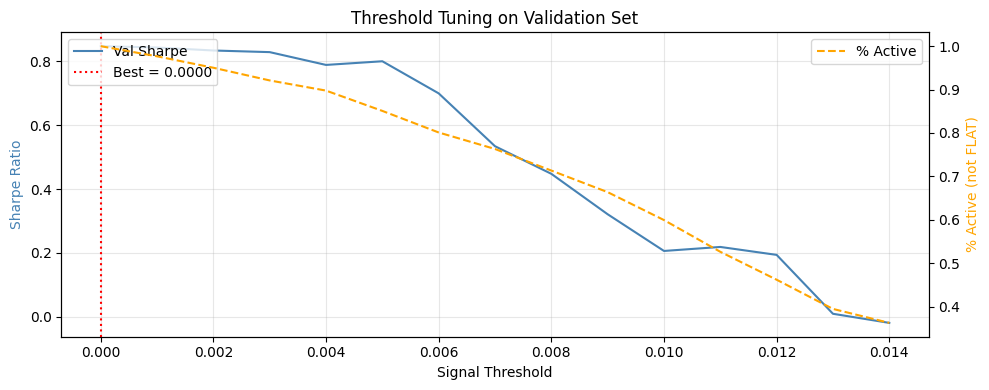

In [13]:
def tune_threshold(true_val, pred_val, thresholds=None):
    """Find the best signal threshold on validation set."""
    if thresholds is None:
        thresholds = np.arange(0.0, 0.015, 0.001)
    
    best_thresh, best_sharpe = 0.0, -np.inf
    results = []
    
    for thresh in thresholds:
        signal = np.where(pred_val > thresh, 1,
                 np.where(pred_val < -thresh, -1, 0))
        # Simple 5-day hold: align signal with 5-day actual return
        strat_ret = signal * true_val
        if strat_ret.std() > 0:
            sharpe = strat_ret.mean() / strat_ret.std() * np.sqrt(252 / FORWARD_DAYS)
        else:
            sharpe = 0
        results.append({'threshold': thresh, 'sharpe': sharpe,
                        'pct_active': np.mean(signal != 0)})
        if sharpe > best_sharpe:
            best_sharpe = sharpe
            best_thresh = thresh
    
    return best_thresh, pd.DataFrame(results)

# Tune on validation set
best_thresh, thresh_df = tune_threshold(true_va, pred_va)
print(f'Best threshold (from val set): {best_thresh:.4f}')
print(f'(This means: only trade when |predicted 5-day return| > {best_thresh:.2%})')

# Plot threshold sensitivity
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
ax1.plot(thresh_df['threshold'], thresh_df['sharpe'], 'steelblue', label='Val Sharpe')
ax2.plot(thresh_df['threshold'], thresh_df['pct_active'], 'orange', linestyle='--', label='% Active')
ax1.axvline(best_thresh, color='red', linestyle=':', label=f'Best = {best_thresh:.4f}')
ax1.set_xlabel('Signal Threshold')
ax1.set_ylabel('Sharpe Ratio', color='steelblue')
ax2.set_ylabel('% Active (not FLAT)', color='orange')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
plt.title('Threshold Tuning on Validation Set')
plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
def run_backtest(true_returns, pred_returns, close_prices, dates,
                 threshold=0.002, label='Strategy v2',
                 transaction_cost=0.001):
    """
    5-day signal backtest with threshold and transaction costs.
    
    Signal is held for FORWARD_DAYS days then re-evaluated.
    transaction_cost = 0.1% per trade (round-trip = 0.2%)
    """
    n = len(true_returns)
    
    # Generate signals using BEST THRESHOLD
    signal = np.where(pred_returns >  threshold,  1,
             np.where(pred_returns < -threshold, -1, 0))
    
    # Convert 5-day signals to daily P&L
    # Each signal is held for FORWARD_DAYS days
    # The actual daily log return comes from the raw df
    daily_pnl = np.zeros(n)
    for i in range(n):
        # Signal at day i → hold position for FORWARD_DAYS
        # true_returns[i] is the 5-day cumulative return
        # We credit 1/5 of it per day (approximation)
        daily_pnl[i] = signal[i] * true_returns[i] / FORWARD_DAYS
    
    # Transaction cost: pay when signal changes
    position_changes = np.diff(signal, prepend=0)
    costs = np.abs(position_changes) * transaction_cost
    daily_pnl -= costs
    
    # Cumulative returns
    strategy_cum = np.cumprod(1 + daily_pnl) - 1
    
    # Buy-and-hold (buy first day, hold to end)
    bh_daily = np.diff(np.log(close_prices), prepend=np.log(close_prices[0])) 
    bh_daily = bh_daily[:n]
    bh_cum = np.cumprod(1 + bh_daily) - 1
    
    # Metrics
    ann_factor = np.sqrt(252)
    pct_active = np.mean(signal != 0)
    
    # Sharpe (annualised)
    sharpe = daily_pnl.mean() / (daily_pnl.std() + 1e-9) * ann_factor
    
    # Max drawdown
    cum_wealth = np.cumprod(1 + daily_pnl)
    running_max = np.maximum.accumulate(cum_wealth)
    drawdown = (cum_wealth - running_max) / running_max
    max_dd = drawdown.min()
    
    # Win rate
    active_days = daily_pnl[signal != 0]
    win_rate = np.mean(active_days > 0) if len(active_days) > 0 else 0
    
    print(f'\n═══ Backtest Results — {label} ═══')
    print(f'  Total return     : {strategy_cum[-1]:.2%}  (Buy&Hold: {bh_cum[-1]:.2%})')
    print(f'  Sharpe ratio     : {sharpe:.3f}')
    print(f'  Max drawdown     : {max_dd:.2%}')
    print(f'  Days active      : {pct_active:.1%} of test period')
    print(f'  Win rate (active): {win_rate:.1%}')
    print(f'  Dir accuracy     : {np.mean(np.sign(true_returns) == np.sign(pred_returns)):.1%}')
    
    return {
        'dates': dates, 'strategy_cum': strategy_cum, 'bh_cum': bh_cum,
        'signal': signal, 'daily_pnl': daily_pnl, 'drawdown': drawdown,
        'sharpe': sharpe, 'max_dd': max_dd, 'pct_active': pct_active,
        'total_ret': strategy_cum[-1], 'bh_ret': bh_cum[-1]
    }

# Run backtest on TEST SET using best threshold tuned on VAL
test_close = test_df['Close'].values[SEQUENCE_LENGTH:]

bt = run_backtest(
    true_returns  = true_te,
    pred_returns  = pred_te,
    close_prices  = test_close,
    dates         = test_dates,
    threshold     = best_thresh,
    label         = 'BiLSTM v2'
)


═══ Backtest Results — BiLSTM v2 ═══
  Total return     : -11.97%  (Buy&Hold: 139.74%)
  Sharpe ratio     : -0.379
  Max drawdown     : -50.76%
  Days active      : 100.0% of test period
  Win rate (active): 52.0%
  Dir accuracy     : 52.0%


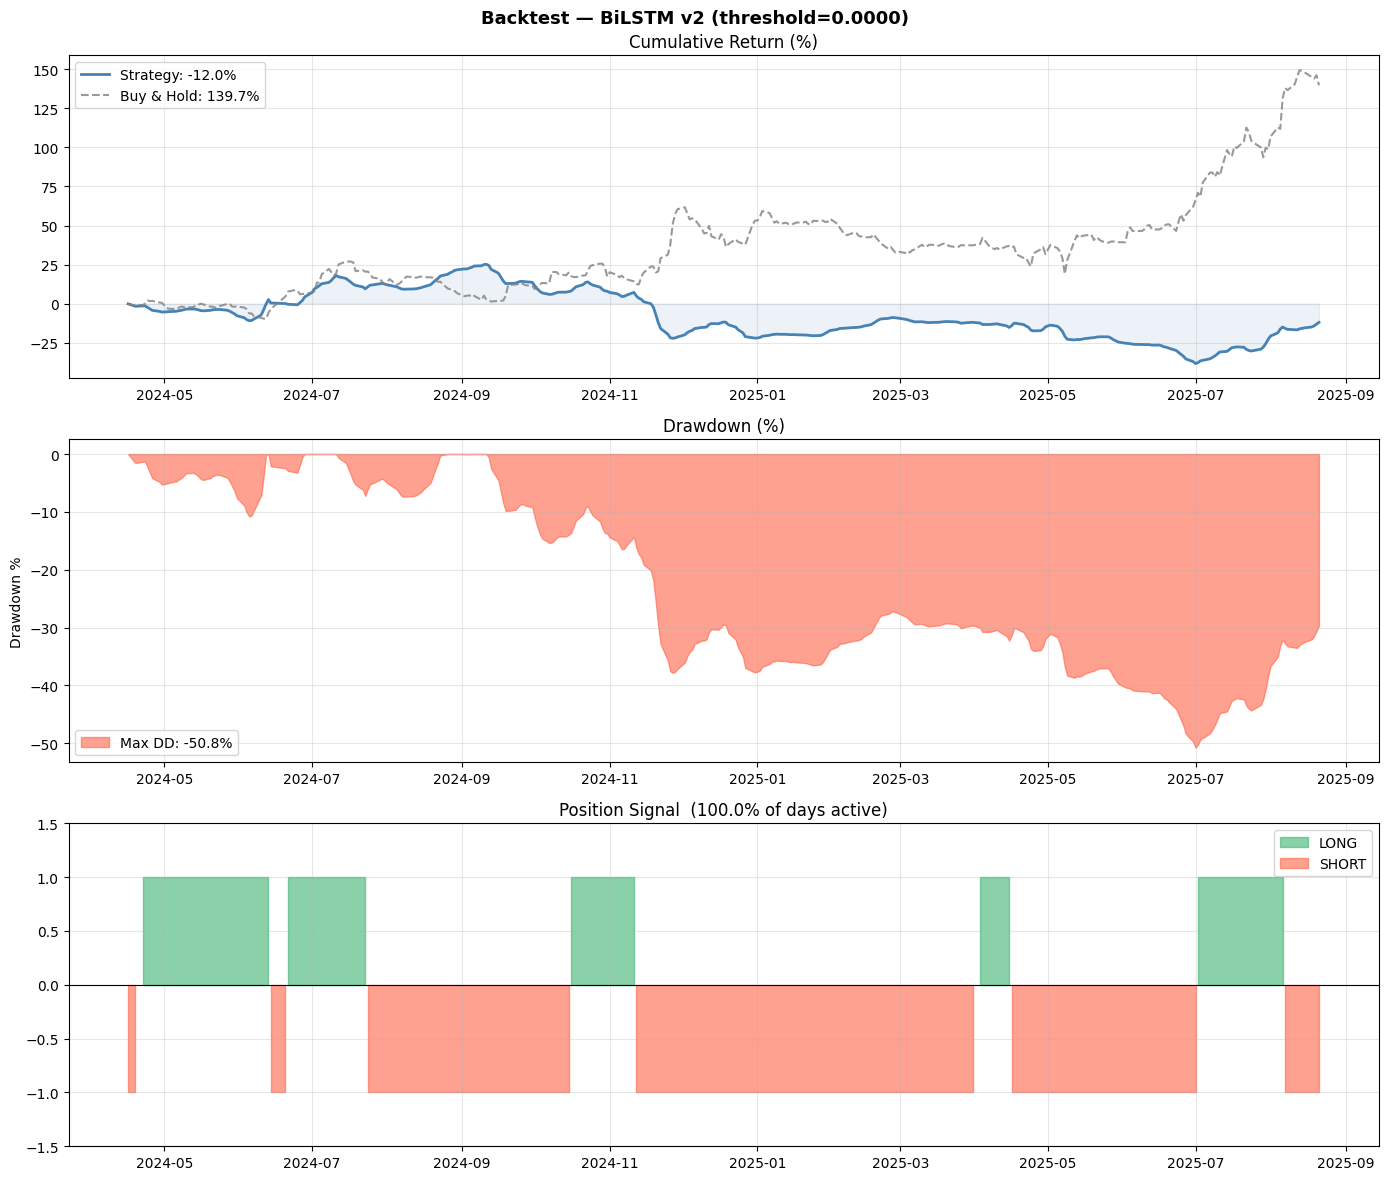

In [15]:
# Plot backtest results
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle(f'Backtest — BiLSTM v2 (threshold={best_thresh:.4f})', fontsize=13, fontweight='bold')

# Cumulative returns
axes[0].plot(bt['dates'], bt['strategy_cum'] * 100, label=f"Strategy: {bt['total_ret']:.1%}",
             color='steelblue', linewidth=2)
axes[0].plot(bt['dates'], bt['bh_cum'] * 100, label=f"Buy & Hold: {bt['bh_ret']:.1%}",
             color='gray', linewidth=1.5, linestyle='--', alpha=0.8)
axes[0].fill_between(bt['dates'], bt['strategy_cum'] * 100, alpha=0.1, color='steelblue')
axes[0].set_title('Cumulative Return (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Drawdown
axes[1].fill_between(bt['dates'], bt['drawdown'] * 100, 0,
                     color='tomato', alpha=0.6, label=f"Max DD: {bt['max_dd']:.1%}")
axes[1].set_title('Drawdown (%)')
axes[1].set_ylabel('Drawdown %')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Position signal
axes[2].fill_between(bt['dates'], bt['signal'], 0,
                     where=(bt['signal'] > 0), color='mediumseagreen', alpha=0.6, label='LONG')
axes[2].fill_between(bt['dates'], bt['signal'], 0,
                     where=(bt['signal'] < 0), color='tomato', alpha=0.6, label='SHORT')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title(f'Position Signal  ({bt["pct_active"]:.1%} of days active)')
axes[2].set_ylim(-1.5, 1.5)
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.savefig('backtest_v2.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 14 — Feature Importance (Permutation)

We measure importance by shuffling one feature at a time and measuring how much
MSE increases. A large increase = the feature was important.
A decrease (negative importance) = the feature was adding noise.

Computing permutation importance (takes ~2 min)...


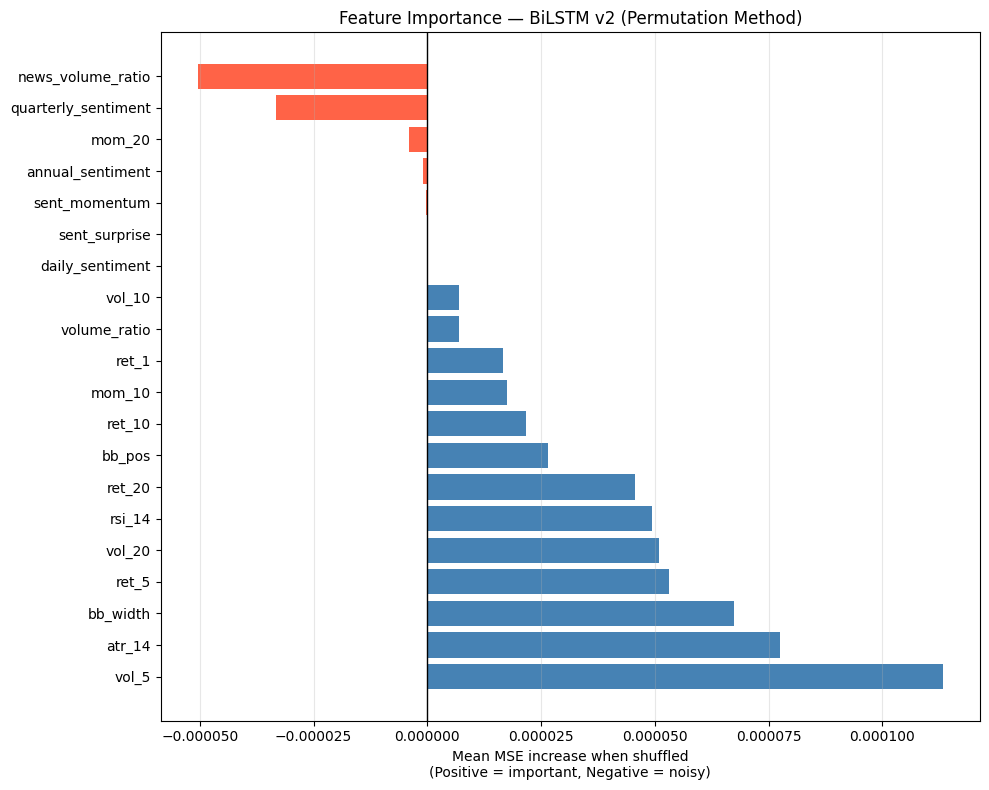


Top 5 most important features:
 feature  importance
   vol_5    0.000113
  atr_14    0.000078
bb_width    0.000067
   ret_5    0.000053
  vol_20    0.000051

Features with negative importance (consider dropping in v3):
            feature    importance
      sent_momentum -3.189780e-07
   annual_sentiment -8.977950e-07
             mom_20 -4.080124e-06
quarterly_sentiment -3.320165e-05
  news_volume_ratio -5.044610e-05


In [16]:
def permutation_importance(model, X, y_true_raw, feature_names, target_scaler, n_repeats=5):
    """Compute permutation feature importance on test set."""
    # Baseline MSE
    base_pred_scaled = model.predict(X, verbose=0)
    base_pred = target_scaler.inverse_transform(base_pred_scaled).flatten()
    base_mse  = mean_squared_error(y_true_raw, base_pred)
    
    importances = []
    for feat_idx in range(X.shape[2]):
        mse_increases = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            # Shuffle this feature across all timesteps and samples
            perm = np.random.permutation(X_perm.shape[0])
            X_perm[:, :, feat_idx] = X_perm[perm, :, feat_idx]
            perm_pred_scaled = model.predict(X_perm, verbose=0)
            perm_pred = target_scaler.inverse_transform(perm_pred_scaled).flatten()
            perm_mse  = mean_squared_error(y_true_raw, perm_pred)
            mse_increases.append(perm_mse - base_mse)
        importances.append(np.mean(mse_increases))
    
    imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    return imp_df.sort_values('importance', ascending=False)

print('Computing permutation importance (takes ~2 min)...')
imp_df = permutation_importance(model, X_te, true_te, FEATURE_COLS, target_scaler, n_repeats=3)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['steelblue' if v >= 0 else 'tomato' for v in imp_df['importance']]
ax.barh(imp_df['feature'], imp_df['importance'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Mean MSE increase when shuffled\n(Positive = important, Negative = noisy)')
ax.set_title('Feature Importance — BiLSTM v2 (Permutation Method)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_importance_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 most important features:')
print(imp_df.head(5).to_string(index=False))
print('\nFeatures with negative importance (consider dropping in v3):')
print(imp_df[imp_df['importance'] < 0].to_string(index=False))

## Section 15 — v1 vs v2 Summary Comparison

In [17]:
# Fill in v1 numbers from your previous run, then run this cell
v1_metrics = {
    'Pearson r (test)': 0.017,
    'R² (test)':        -0.041,
    'Dir Acc (test)':   0.516,
    'Backtest Return':  0.86,
    'Buy&Hold Return':  1.56,
    'Sharpe':           2.077,
    'Max Drawdown':    -0.107,
}

v2_metrics = {
    'Pearson r (test)': results_df.loc['Test', 'Pearson r'],
    'R² (test)':        results_df.loc['Test', 'R²'],
    'Dir Acc (test)':   results_df.loc['Test', 'Dir Acc'],
    'Backtest Return':  bt['total_ret'],
    'Buy&Hold Return':  bt['bh_ret'],
    'Sharpe':           bt['sharpe'],
    'Max Drawdown':     bt['max_dd'],
}

comp = pd.DataFrame({'v1 (next-day, MSE)': v1_metrics,
                     'v2 (5-day, Dir Loss)': v2_metrics})
print('\n═══ v1 vs v2 Comparison ═══')
print(comp.to_string(float_format=lambda x: f'{x:.4f}'))
print('\n✅ Positive Pearson r and R² > 0 indicate genuine improvement over naive baseline')


═══ v1 vs v2 Comparison ═══
                  v1 (next-day, MSE)  v2 (5-day, Dir Loss)
Pearson r (test)              0.0170                0.0884
R² (test)                    -0.0410               -0.0867
Dir Acc (test)                0.5160                0.5205
Backtest Return               0.8600               -0.1197
Buy&Hold Return               1.5600                1.3974
Sharpe                        2.0770               -0.3791
Max Drawdown                 -0.1070               -0.5076

✅ Positive Pearson r and R² > 0 indicate genuine improvement over naive baseline


## Section 16 — Save Artifacts

In [18]:
import pickle

# Model already saved by ModelCheckpoint callback
# Re-save scalers with metadata
artifacts = {
    'feature_scaler': feature_scaler,
    'target_scaler':  target_scaler,
    'feature_cols':   FEATURE_COLS,
    'target_col':     TARGET_COL,
    'seq_len':        SEQUENCE_LENGTH,
    'forward_days':   FORWARD_DAYS,
    'signal_threshold': best_thresh,
    'direction_weight': DIRECTION_WEIGHT,
    'test_metrics':   results_df.loc['Test'].to_dict(),
}
with open(SCALER_SAVE_PATH, 'wb') as f:
    pickle.dump(artifacts, f)

print('✅ All artifacts saved')
print(f'   Model  : {MODEL_SAVE_PATH}')
print(f'   Scalers: {SCALER_SAVE_PATH}')
print(f'\nTo load for inference:')
print("""
import pickle, tensorflow as tf

with open(SCALER_SAVE_PATH, 'rb') as f:
    artifacts = pickle.load(f)

def directional_loss(direction_weight=0.7):
    import tensorflow.keras.backend as K
    def loss(y_true, y_pred):
        mse = K.mean(K.square(y_true - y_pred))
        direction_penalty = K.mean(K.relu(-y_true * y_pred))
        return mse + direction_weight * direction_penalty
    return loss

model = tf.keras.models.load_model(
    MODEL_SAVE_PATH,
    custom_objects={'loss': directional_loss(0.7)}
)
""")

✅ All artifacts saved
   Model  : hbl_merged_dataset_clean\bilstm_return_regression.keras
   Scalers: C:\Users\Admin\Desktop\Fyp Working\model training v3\feature_scaler.pkl

To load for inference:

import pickle, tensorflow as tf

with open(SCALER_SAVE_PATH, 'rb') as f:
    artifacts = pickle.load(f)

def directional_loss(direction_weight=0.7):
    import tensorflow.keras.backend as K
    def loss(y_true, y_pred):
        mse = K.mean(K.square(y_true - y_pred))
        direction_penalty = K.mean(K.relu(-y_true * y_pred))
        return mse + direction_weight * direction_penalty
    return loss

model = tf.keras.models.load_model(
    MODEL_SAVE_PATH,
    custom_objects={'loss': directional_loss(0.7)}
)



## Section 17 — What to Try Next (v3 Ideas)

After running this notebook, here are the next improvement ideas ordered by expected impact:

### 1. Tune `DIRECTION_WEIGHT` (Quick)
Try values: 0.3, 0.5, 0.7, 1.0, 1.5. Use validation Pearson r as the selection metric.
Higher weights force more directional accuracy but may hurt magnitude accuracy.

### 2. Drop features with negative importance from Section 14
Re-run with those features removed. Smaller feature sets often generalise better.

### 3. Try 10-day target
Change `FORWARD_DAYS = 10`. Longer horizons carry more fundamental signal.
The trade-off: fewer non-overlapping samples → model may overfit.

### 4. Add macro features
- PSX index return (market beta)
- USD/PKR exchange rate change
- Oil price change (HBL has commodity exposure)
These would require additional data collection.

### 5. Ensemble: Average v2 predictions with a simple XGBoost model
XGBoost on the same feature set often captures non-linear patterns that LSTMs miss.
Averaging two diverse models typically improves robustness.

### 6. Walk-forward validation
Instead of a single train/val/test split, use expanding window validation
to get a more realistic estimate of out-of-sample performance.